<a href="https://colab.research.google.com/github/Aravindr017/CNN_ModelBuilding_CIFAR-100_dataset/blob/main/Model/ComputerVision_cifar_100(dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [25]:
import tensorflow as tf
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split


# Reading Data

In [35]:

# Load Dataset

IMG_SIZE = 32   # reduce the image size to increase the training speed
BATCH_SIZE = 128
TOTAL_IMAGES = 6000

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Combine original train and test sets and convert to NumPy arrays
X = tf.concat([x_train, x_test], axis=0).numpy()
y = tf.concat([y_train, y_test], axis=0).numpy()

# Select only the first 6000 images
X = X[:TOTAL_IMAGES]
y = y[:TOTAL_IMAGES]

# after combining the data and selecting 6000 images split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocessing function to resize and normalize images
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Create TensorFlow datasets
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(preprocess)    # to do preprocessing on the train data
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)   # increase the evaluation speed
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(preprocess)    # to do preprocessing on the test data
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)   # increase the evaluation speed
)

# Get the number of classes.
num_classes = len(tf.unique(tf.reshape(y_train, [-1]))[0])
print(f'Number of classes : {num_classes}')


Number of classes : 100


# Model Building - Custom CNN

In [36]:
# Custom CNN Model - Tensorflow

model = tf.keras.Sequential([

    # Layer 1
    tf.keras.layers.Conv2D(
        16,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.01),
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    # Layer 2
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.30),

    # Layer 3
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.35),

    # Fully Connected Layer
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation='relu',
        kernel_initializer='he_normal'
    ),

    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_custom_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=40,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 184ms/step - accuracy: 0.0096 - loss: 6.2657 - val_accuracy: 0.0117 - val_loss: 4.9606
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 219ms/step - accuracy: 0.0131 - loss: 4.7389 - val_accuracy: 0.0133 - val_loss: 4.6375
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.0133 - loss: 4.6217 - val_accuracy: 0.0133 - val_loss: 4.6168
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 271ms/step - accuracy: 0.0133 - loss: 4.6165 - val_accuracy: 0.0133 - val_loss: 4.6032
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 202ms/step - accuracy: 0.0133 - loss: 4.6544 - val_accuracy: 0.0133 - val_loss: 4.6131
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - accuracy: 0.0133 - loss: 4.6063 - val_accuracy: 0.0133 - val_loss: 4.6082
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - accuracy: 0.0133 - loss: 4.6050 - val_accuracy: 0.0133 - val_loss: 4.6038
Epoch 8/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.0133 - loss: 4.6081 - val_accuracy:

In [38]:
# Evaluate on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0133 - loss: 4.5985
Test Loss     : 4.5985
Test Accuracy : 1.33%


## Plots - Training and Validation

- Loss and accuracy plots

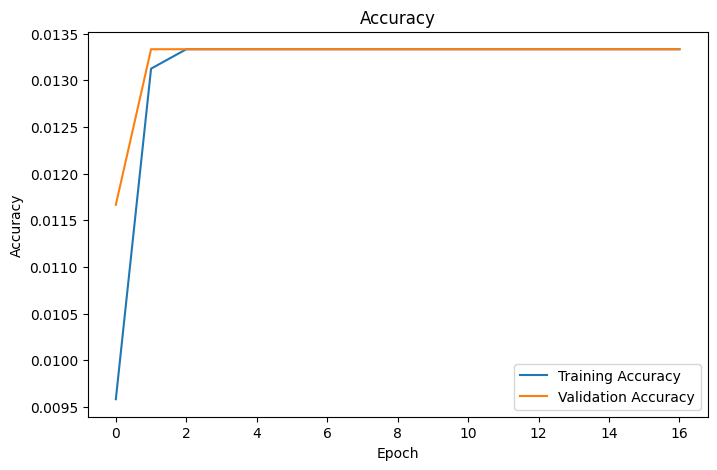

In [39]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

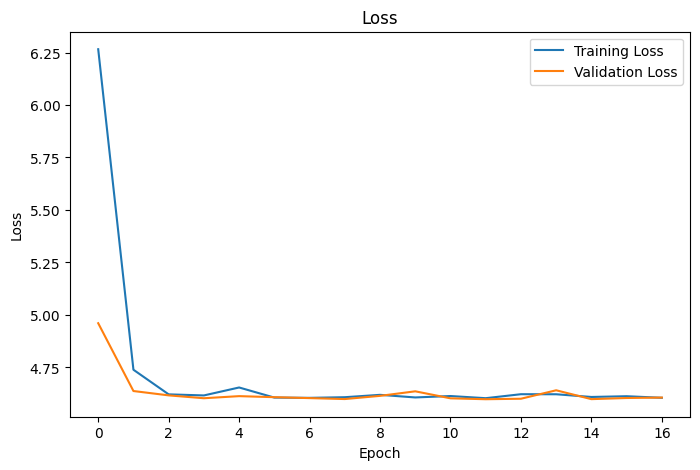

In [40]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Model Summary

In [41]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 935,950 (3.57 MB)

 Trainable params: 311,908 (1.19 MB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 623,818 (2.38 MB)

# Predefined Architecture(VGG-16)

In [42]:
# Load the model

base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [43]:
# Freeze pretrained convolutional layers
base_model.trainable = False

# the weights will not change during training.

In [52]:
# Building the model


vgg_model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

In [53]:
# compile the model

vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_vgg16.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
# train the model
print("Training Started...")

history_vgg = vgg_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=40,
    callbacks=[early_stop, checkpoint]
)

Training Started...
Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.0206 - loss: 4.6164 - val_accuracy: 0.0575 - val_loss: 4.4670
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.0485 - loss: 4.3815 - val_accuracy: 0.0975 - val_loss: 4.2196
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.0871 - loss: 4.1351 - val_accuracy: 0.1317 - val_loss: 3.9594
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.1042 - loss: 3.9247 - val_accuracy: 0.1575 - val_loss: 3.7974
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.1348 - loss: 3.7526 - val_accuracy: 0.1800 - val_loss: 3.6509
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.1458 - loss: 3.6401 - val_accuracy: 0.1892 - val_loss: 3.5662
Epoch 7/40
35/38 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.1636 - loss: 3.5596

In [ ]:
# evaluate the model

test_loss, test_accuracy = vgg_model.evaluate(test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

In [ ]:
# save the model

vgg_model.save("vgg16_cifar100.keras")

print("Model Saved Successfully")

## Model summary

In [46]:
vgg_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,028,644 (57.33 MB)

 Trainable params: 313,956 (1.20 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Making Predictions using the model

## Predictions Using Custom CNN

In [47]:
# Get one batch from the test dataset
images, labels = next(iter(test_dataset))

# Predict using the custom CNN
predictions = model.predict(images)

# Select an image
index = 0

# Get predicted and actual labels
predicted_class = np.argmax(predictions[index])
true_class = labels[index].numpy()[0]

# Display the image
plt.imshow(images[index])
plt.axis('off')
plt.title(f"Actual: {class_names[true_class]}\nPredicted: {class_names[predicted_class]}")
plt.show()

print(f"Actual Label    : {class_names[true_class]}")
print(f"Predicted Label : {class_names[predicted_class]}")
print(f"Confidence      : {np.max(predictions[index])*100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


## Predictions using VGG-16

In [ ]:
# Get one batch from the test dataset
images, labels = next(iter(test_dataset))

# Predict
predictions = vgg_model.predict(images)

# Select an image
index = 0

predicted_class = np.argmax(predictions[index])
true_class = labels[index].numpy()[0]

# Display image
plt.imshow(images[index])
plt.axis("off")

plt.title(f"Actual: {true_class} | Predicted: {predicted_class}")
plt.show()

print(f"Actual Label    : {true_class}")
print(f"Predicted Label : {predicted_class}")
print(f"Confidence      : {np.max(predictions[index])*100:.2f}%")

# Evaluating The model

## Custom CNN

## VGG-16